In [5]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images :", X_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", X_test.shape)
print("Testing labels  :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)


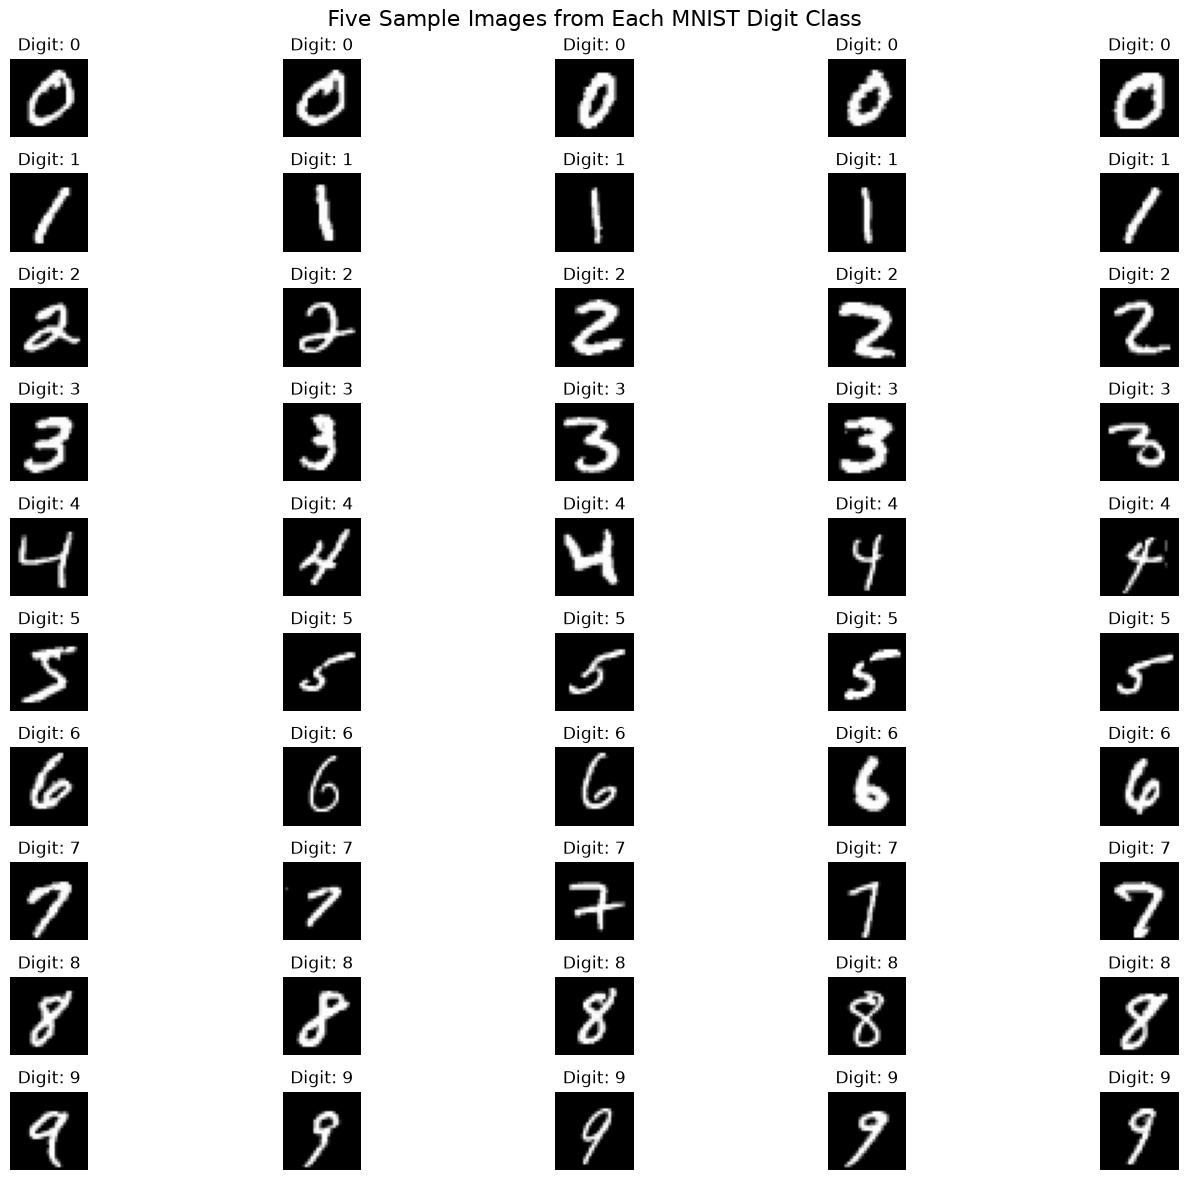

In [4]:
plt.figure(figsize=(15, 12))

for digit in range(10):

    # Find indices of images belonging to the current digit
    indices = np.where(y_train == digit)[0][:5]

    for j, idx in enumerate(indices):

        plt.subplot(10, 5, digit * 5 + j + 1)

        plt.imshow(X_train[idx], cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

plt.suptitle("Five Sample Images from Each MNIST Digit Class", fontsize=16)
plt.tight_layout()
plt.show()

Preprocess Data

Logistic Regression expects a 1D feature vector, so flatten each 28×28 image into a vector of length 784.

Also normalize pixel values.

In [6]:
X_train = X_train.reshape(60000, 784) / 255.0
X_test = X_test.reshape(10000, 784) / 255.0

Train Logistic Regression Model

In [8]:
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Prediction

In [9]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [10]:
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy :", train_accuracy)

Training Accuracy : 0.9385833333333333


In [11]:
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy :", test_accuracy)

Testing Accuracy : 0.9265


Prediction Analysis

In [12]:
cm = confusion_matrix(y_test, test_pred)

print(cm)

[[ 958    0    1    3    1    9    4    3    1    0]
 [   0 1111    4    2    0    2    3    2   11    0]
 [   6    9  931   16   10    3   12    9   32    4]
 [   4    1   16  924    1   24    2   10   20    8]
 [   1    3    8    3  922    0    5    5    6   29]
 [   9    2    3   35    9  778   15    6   31    4]
 [   8    3    8    2    7   16  911    2    1    0]
 [   1    6   23    7    6    1    0  950    3   31]
 [  10   11    6   20    8   28   14   10  855   12]
 [   9    7    1    9   22    7    0   21    8  925]]


In [13]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.92      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



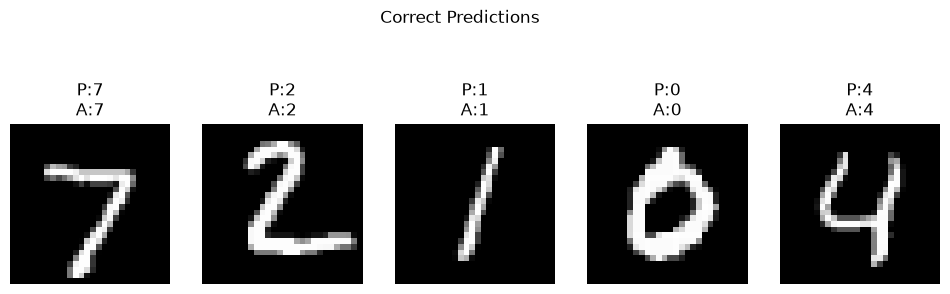

In [15]:
correct = np.where(test_pred == y_test)[0]

plt.figure(figsize=(12,4))

for i in range(5):

    idx = correct[i]

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{test_pred[idx]}\nA:{y_test[idx]}")
    plt.axis('off')

plt.suptitle("Correct Predictions")
plt.show()

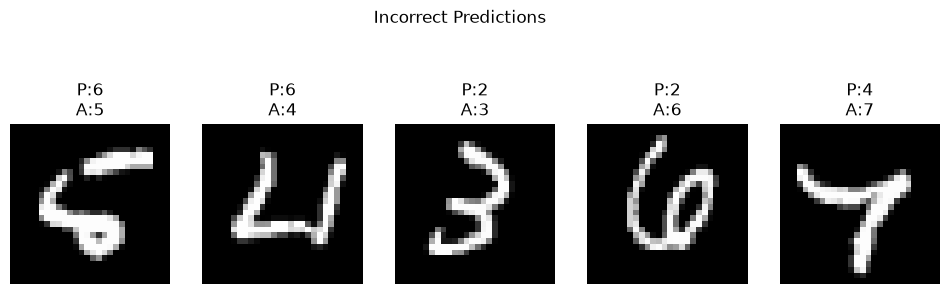

In [16]:
incorrect = np.where(test_pred != y_test)[0]

plt.figure(figsize=(12,4))

for i in range(5):

    idx = incorrect[i]

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"P:{test_pred[idx]}\nA:{y_test[idx]}")
    plt.axis('off')

plt.suptitle("Incorrect Predictions")
plt.show()